#SAM FINE-TUNE

##Set up environment

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!nvidia-smi  # Confirm GPU is enabled

Mon Dec  8 14:29:04 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   65C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install git+https://github.com/facebookresearch/segment-anything.git
!pip install torch torchvision pycocotools opencv-python matplotlib tqdm

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-ohjeyc_p
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-ohjeyc_p
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36592 sha256=21565e24c9f67a0367cca512fcfd7b0971b5408b680e146401f4d832cca67d0b
  Stored in directory: /tmp/pip-ephem-wheel-cache-hkjq_and/wheels/29/82/ff/04e2be9805a1cb48bec0b85b5a6da6b63f647645750a0e42d4
Successfully built segment_anything


##Dataset

In [ ]:
import os

os.makedirs("datasets/coco/images/train2017", exist_ok=True)
os.makedirs("datasets/coco/images/val2017", exist_ok=True)
os.makedirs("datasets/coco/annotations", exist_ok=True)

# Download COCO Train/Val
!wget -O train2017.zip http://images.cocodataset.org/zips/train2017.zip
!wget -O val2017.zip http://images.cocodataset.org/zips/val2017.zip
!wget -O annotations.zip http://images.cocodataset.org/annotations/annotations_trainval2017.zip

!unzip -q train2017.zip -d datasets/coco/images/
!unzip -q val2017.zip -d datasets/coco/images/
!unzip -q annotations.zip -d datasets/coco/


--2025-12-08 14:29:30--  http://images.cocodataset.org/zips/train2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 52.217.172.65, 3.5.30.80, 52.217.235.73, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|52.217.172.65|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19336861798 (18G) [application/zip]
Saving to: ‘train2017.zip’

train2017.zip       100%[===================>]  18.01G  15.9MB/s    in 29m 45s 

2025-12-08 14:59:15 (10.3 MB/s) - ‘train2017.zip’ saved [19336861798/19336861798]

--2025-12-08 14:59:15--  http://images.cocodataset.org/zips/val2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 52.216.24.100, 52.217.138.89, 52.217.162.73, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|52.216.24.100|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 815585330 (778M) [application/zip]
Saving to: ‘val2017.zip’

val2017.zip         100%[===================>] 777.

##Model Checkpoint

In [ ]:
!mkdir -p weights
# replace URL with the official vit_b link from the repo; example placeholder:
!wget -O weights/sam_vit_b_01ec64.pth https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

--2025-12-08 15:05:17--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 18.172.202.93, 18.172.202.63, 18.172.202.76, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|18.172.202.93|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘weights/sam_vit_b_01ec64.pth’

weights/sam_vit_b_0 100%[===================>] 357.67M   141MB/s    in 2.5s    

2025-12-08 15:05:20 (141 MB/s) - ‘weights/sam_vit_b_01ec64.pth’ saved [375042383/375042383]



##Fine-Tune SAM

In [ ]:
import matplotlib.pyplot as plt

# Lists to store metrics
dice_history = []
iou_history = []
epochs_history = []

def plot_metrics(dice_history, iou_history, epochs_history):
    plt.figure(figsize=(10,5))
    plt.plot(epochs_history, dice_history, label="Dice Score", marker='o')
    plt.plot(epochs_history, iou_history, label="IoU Score", marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title("Segmentation Metrics Over Epochs")
    plt.ylim(0,1)
    plt.grid(True)
    plt.legend()
    plt.show()


In [ ]:
import torch

def dice_score(pred, target, threshold=0.5, smooth=1e-6):
    pred_bin = (torch.sigmoid(pred) > threshold).float()
    target = target.float()
    intersection = (pred_bin * target).sum(dim=(1,2,3))
    union = pred_bin.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    return ((2 * intersection + smooth) / (union + smooth)).mean().item()

def iou_score(pred, target, threshold=0.5, smooth=1e-6):
    pred_bin = (torch.sigmoid(pred) > threshold).float()
    target = target.float()
    intersection = (pred_bin * target).sum(dim=(1,2,3))
    union = (pred_bin + target - pred_bin*target).sum(dim=(1,2,3))
    return ((intersection + smooth) / (union + smooth)).mean().item()


In [ ]:
def evaluate_sam(sam_model, dataloader, device):
    sam_model.eval()
    dice_scores = []
    iou_scores = []

    with torch.no_grad():
        for imgs, masks in dataloader:
            imgs = imgs.to(device)
            masks = masks.to(device)

            # Image encoder (frozen)
            image_embeddings = sam_model.image_encoder(imgs)
            image_pe = sam_model.prompt_encoder.get_dense_pe().to(device)

            batch_size = imgs.shape[0]
            embed_dim = sam_model.prompt_encoder.embed_dim

            sparse_prompt_embeddings = torch.zeros((batch_size, 0, embed_dim), device=device)
            dense_prompt_embeddings = torch.zeros(
                (batch_size, embed_dim, image_pe.shape[-2], image_pe.shape[-1]), device=device
            )

            masks_pred, _ = sam_model.mask_decoder(
                image_embeddings=image_embeddings,
                image_pe=image_pe,
                sparse_prompt_embeddings=sparse_prompt_embeddings,
                dense_prompt_embeddings=dense_prompt_embeddings,
                multimask_output=False
            )

            # Resize to GT size
            if masks_pred.shape[-2:] != masks.shape[-2:]:
                masks_pred = torch.nn.functional.interpolate(
                    masks_pred, size=masks.shape[-2:], mode="bilinear", align_corners=False
                )

            dice_scores.append(dice_score(masks_pred, masks))
            iou_scores.append(iou_score(masks_pred, masks))

    avg_dice = sum(dice_scores) / len(dice_scores)
    avg_iou = sum(iou_scores) / len(iou_scores)
    return avg_dice, avg_iou


Using device: cuda


Epoch 1/10:   1%|          | 6/500 [00:04<04:10,  1.97it/s, loss=1.36]

RLE decode error: Expected bytes, got list


Epoch 1/10:   2%|▏         | 9/500 [00:05<03:26,  2.37it/s, loss=1.65]

RLE decode error: Expected bytes, got list


...

RLE decode error: Expected bytes, got list


Epoch 10/10:  98%|█████████▊| 490/500 [03:29<00:04,  2.34it/s, loss=1.42]

RLE decode error: Expected bytes, got list


Epoch 10/10: 100%|██████████| 500/500 [03:33<00:00,  2.34it/s, loss=0.115]


RLE decode error: Expected bytes, got list
RLE decode error: Expected bytes, got list
RLE decode error: Expected bytes, got list
RLE decode error: Expected bytes, got list
RLE decode error: Expected bytes, got list
RLE decode error: Expected bytes, got list
RLE decode error: Expected bytes, got list
RLE decode error: Expected bytes, got list
RLE decode error: Expected bytes, got list
Epoch 10/10 - Loss: 0.4881 | Dice: 0.8060 | IoU: 0.7038


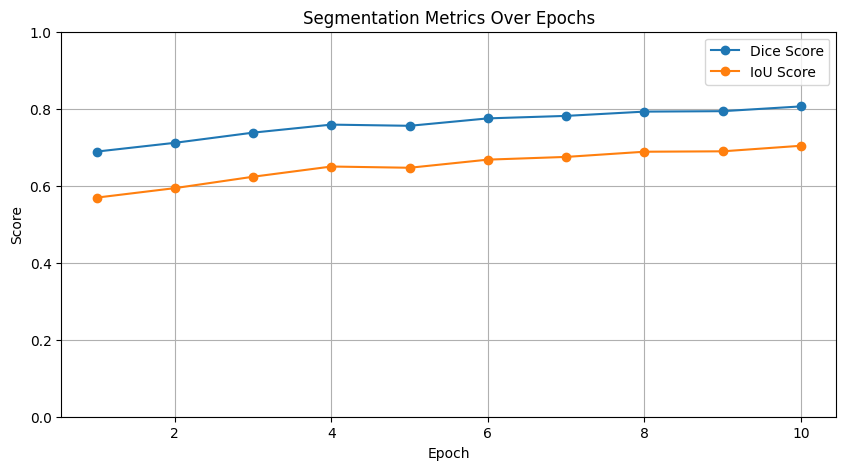

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import ToTensor
import cv2
import numpy as np
import pycocotools.mask
from tqdm import tqdm
import os
import json
from segment_anything import sam_model_registry
from torch.utils.data import random_split
import random
from pycocotools import mask as maskUtils

# ---------------------------
# Settings
# ---------------------------
MODEL_TYPE = "vit_b"
CHECKPOINT_PATH = "weights/sam_vit_b_01ec64.pth"
SAM_INPUT_SIZE = 1024
BATCH_SIZE = 1        # Adjust for GPU/MPS memory
EPOCHS = 10
LEARNING_RATE = 1e-5
SAVE_DIR = "/content/drive/MyDrive/SAM_checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

IMG_DIR = "datasets/coco/images/train2017"
ANN_PATH = "datasets/coco/annotations/instances_train2017.json"

# ---------------------------
# Device setup
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else
                      "mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)


# ---------------------------
# Dataset
# ---------------------------
coco = json.load(open(ANN_PATH))

# Number of images you want to use
N = 500

# Shuffle and take first N images
subset_images = random.sample(coco["images"], N)

# Filter annotations for selected images
subset_img_ids = {img["id"] for img in subset_images}
subset_annotations = [ann for ann in coco["annotations"] if ann["image_id"] in subset_img_ids]

# Create a smaller COCO dict
coco_subset = {
    "images": subset_images,
    "annotations": subset_annotations,
    "categories": coco["categories"]
}

class CocoSegDataset(Dataset):
    def __init__(self, coco, img_dir):
        self.coco = coco
        self.img_dir = img_dir
        self.images = coco["images"]
        self.annotations = coco["annotations"]

        self.img_to_anns = {}
        for ann in self.annotations:
            self.img_to_anns.setdefault(ann["image_id"], []).append(ann)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_path = os.path.join(self.img_dir, img_info["file_name"])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = np.zeros((img_info["height"], img_info["width"]), dtype=np.uint8)
        anns = self.img_to_anns.get(img_info["id"], [])

        for ann in anns:
            seg = ann["segmentation"]

            if isinstance(seg, list):
                # Polygon format
                for poly in seg:
                    poly = np.array(poly).reshape((-1,2))
                    cv2.fillPoly(mask, [poly.astype(np.int32)], 1)

            elif isinstance(seg, dict):
                # RLE format (compressed or uncompressed)
                try:
                    m = maskUtils.decode(seg)
                    mask = np.maximum(mask, m)
                except Exception as e:
                    print("RLE decode error:", e)
                    continue
            else:
                # Unexpected format
                continue
                # Resize to SAM input
        img = cv2.resize(img, (SAM_INPUT_SIZE, SAM_INPUT_SIZE))
        mask = cv2.resize(mask, (SAM_INPUT_SIZE, SAM_INPUT_SIZE))

        img = ToTensor()(img)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return img, mask

dataset = CocoSegDataset(coco_subset, IMG_DIR)

# Let's split 80% train, 20% validation
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
dataloader_val = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
# ---------------------------
# Loss functions
# ---------------------------
bce = nn.BCEWithLogitsLoss()

def dice_loss(pred, target, smooth=1e-6):
    pred = torch.sigmoid(pred)
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()
    return 1 - (2 * intersection + smooth) / (union + smooth)

# ---------------------------
# Load SAM
# ---------------------------
sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH)
sam.to(device)

# Freeze image encoder
for param in sam.image_encoder.parameters():
    param.requires_grad = False

optimizer = torch.optim.Adam(sam.mask_decoder.parameters(), lr=LEARNING_RATE)

# ---------------------------
# Training loop
# ---------------------------
for epoch in range(1, EPOCHS+1):
    sam.train()
    running_loss = 0.0
    pbar = tqdm(dataloader, desc=f"Epoch {epoch}/{EPOCHS}")

    for imgs, masks in pbar:
        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        # ---------------------------
        # Forward pass
        # ---------------------------
        with torch.no_grad():
            image_embeddings = sam.image_encoder(imgs)  # frozen

        image_pe = sam.prompt_encoder.get_dense_pe().to(device)

        batch_size = imgs.shape[0]
        embed_dim = sam.prompt_encoder.embed_dim

        sparse_prompt_embeddings = torch.zeros((batch_size, 0, embed_dim), device=device)
        dense_prompt_embeddings = torch.zeros(
            (batch_size, embed_dim, image_pe.shape[-2], image_pe.shape[-1]), device=device
        )

        masks_pred, _ = sam.mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=image_pe,
            sparse_prompt_embeddings=sparse_prompt_embeddings,
            dense_prompt_embeddings=dense_prompt_embeddings,
            multimask_output=False
        )

        # Resize mask logits to GT size if needed
        if masks_pred.shape[-2:] != masks.shape[-2:]:
            masks_pred = nn.functional.interpolate(
                masks_pred, size=masks.shape[-2:], mode="bilinear", align_corners=False
            )

        loss = bce(masks_pred, masks) + dice_loss(masks_pred, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    avg_loss = running_loss / len(dataloader)

    # ---------------------------
    # Validation after epoch
    # ---------------------------
    dice_val, iou_val = evaluate_sam(sam, dataloader_val, device)
    print(f"Epoch {epoch}/{EPOCHS} - Loss: {avg_loss:.4f} | Dice: {dice_val:.4f} | IoU: {iou_val:.4f}")

    # Save metrics
    dice_history.append(dice_val)
    iou_history.append(iou_val)
    epochs_history.append(epoch)

    # Save checkpoint
    torch.save(sam.state_dict(), os.path.join(SAVE_DIR, f"sam_{MODEL_TYPE}_epoch{epoch}.pth"))

# ---------------------------
# Plot Dice & IoU over epochs
# ---------------------------
plot_metrics(dice_history, iou_history, epochs_history)


In [ ]:
!ls /content/drive/MyDrive/SAM_checkpoints

sam_vit_b_epoch10.pth  sam_vit_b_epoch4.pth  sam_vit_b_epoch8.pth
sam_vit_b_epoch1.pth   sam_vit_b_epoch5.pth  sam_vit_b_epoch9.pth
sam_vit_b_epoch2.pth   sam_vit_b_epoch6.pth
sam_vit_b_epoch3.pth   sam_vit_b_epoch7.pth


#Image Processing with Trained Model

In [ ]:
import torch
from segment_anything import sam_model_registry, SamPredictor
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Paths
MODEL_TYPE = "vit_b"
CKPT = "/content/drive/MyDrive/SAM_checkpoints/sam_vit_b_epoch10.pth"  # your trained checkpoint
DEVICE = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

# Load SAM
#sam = sam_model_registry[MODEL_TYPE](checkpoint="weights/sam_vit_b_01ec64.pth")  # base checkpoint
sam = sam_model_registry[MODEL_TYPE](checkpoint=None)
sam.load_state_dict(torch.load(CKPT, map_location=DEVICE))  # load your trained weights
sam.to(DEVICE)
sam.eval()  # inference mode

Sam(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): Linear(in_features=3072, out_features=768, bias=True)
          (act): GELU(approximate='none')
        )
      )
    )
    (neck): Sequential(
      (0): Conv2d(768, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): LayerNorm2d()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): LayerNorm2d()
    )


In [ ]:
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0,0,0,0), lw=2))


###Image

In [ ]:
!mkdir images
!wget -P images https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/truck.jpg
!wget -P images https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/groceries.jpg

--2025-12-08 15:54:07--  https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/truck.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 271475 (265K) [image/jpeg]
Saving to: ‘images/truck.jpg’

truck.jpg           100%[===================>] 265.11K  --.-KB/s    in 0.005s  

2025-12-08 15:54:07 (56.0 MB/s) - ‘images/truck.jpg’ saved [271475/271475]

--2025-12-08 15:54:07--  https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/groceries.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaitin

In [ ]:
!ls

annotations.zip  drive	 sample_data	val2017.zip
datasets	 images  train2017.zip	weights


In [ ]:
image = cv2.imread('images/truck.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

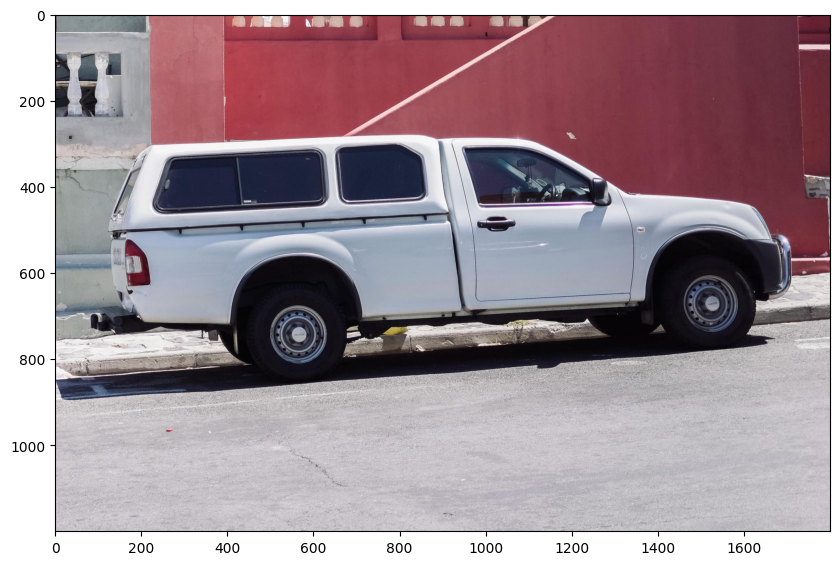

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow(image)
plt.axis('on')
plt.show()

In [ ]:
predictor = SamPredictor(sam)

In [ ]:
predictor.set_image(image)

##Prompt Engineering - Point

In [ ]:
input_point = np.array([[500, 375]])
input_label = np.array([1])

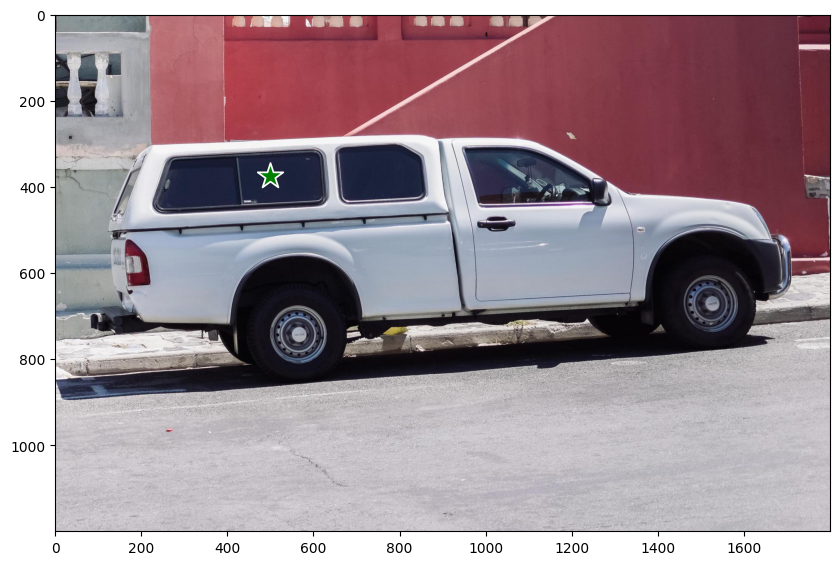

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow(image)
show_points(input_point, input_label, plt.gca())
plt.axis('on')
plt.show()

In [ ]:
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True,
)

In [ ]:
masks.shape  # (number_of_masks) x H x W

(3, 1200, 1800)

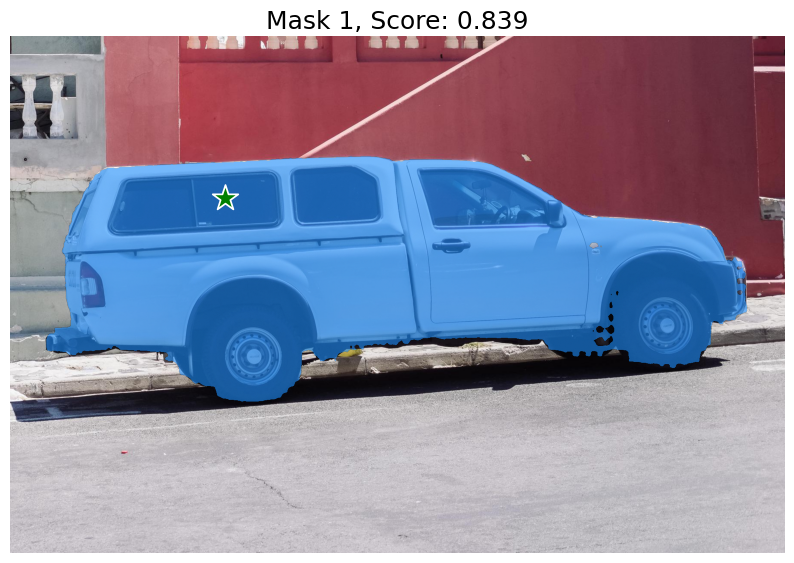

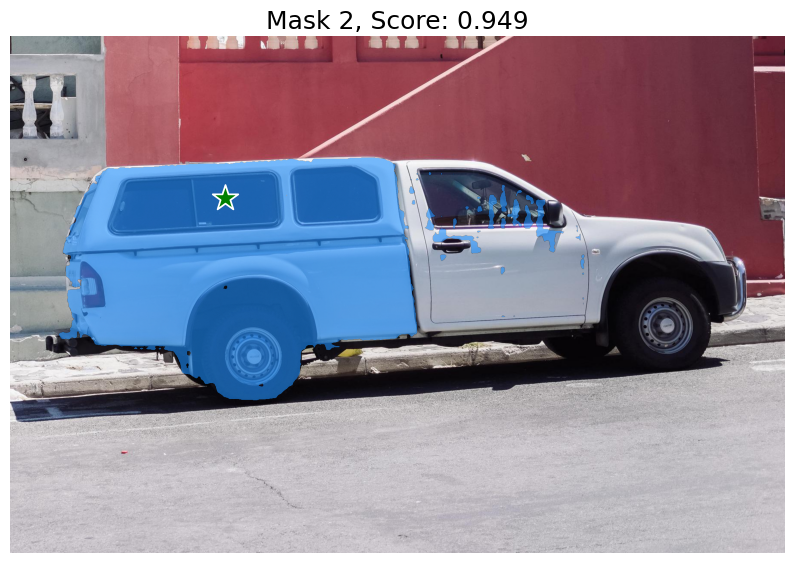

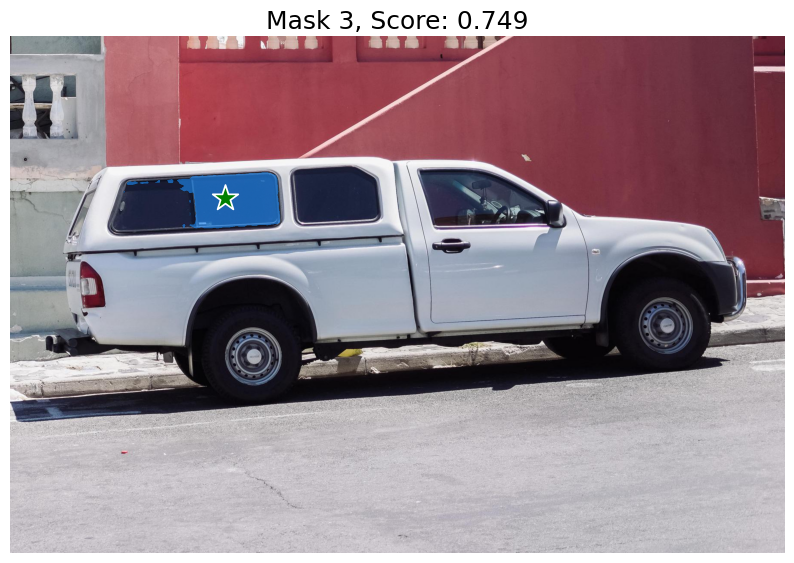

In [ ]:
for i, (mask, score) in enumerate(zip(masks, scores)):
    plt.figure(figsize=(10,10))
    plt.imshow(image)
    show_mask(mask, plt.gca())
    show_points(input_point, input_label, plt.gca())
    plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
    plt.axis('off')
    plt.show()


##Multiple Points

In [ ]:
input_point = np.array([[500, 375], [1125, 625]])
input_label = np.array([1, 1])

mask_input = logits[np.argmax(scores), :, :]  # Choose the model's best mask

In [ ]:
masks, _, _ = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    mask_input=mask_input[None, :, :],
    multimask_output=False,
)

In [ ]:
masks.shape

(1, 1200, 1800)

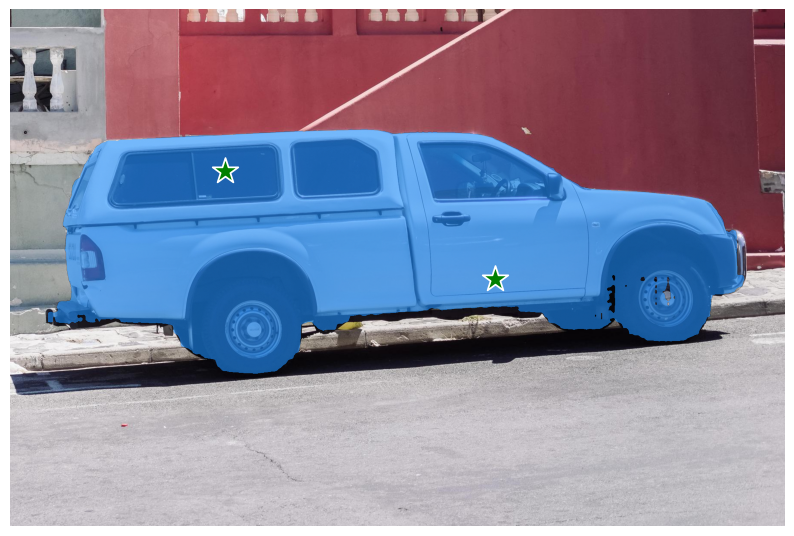

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow(image)
show_mask(masks, plt.gca())
show_points(input_point, input_label, plt.gca())
plt.axis('off')
plt.show()

##Foreground Vs Background

In [ ]:
input_point = np.array([[500, 375], [1125, 625]])
input_label = np.array([1, 0])

mask_input = logits[np.argmax(scores), :, :]  # Choose the model's best mask

In [ ]:
masks, _, _ = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    mask_input=mask_input[None, :, :],
    multimask_output=False,
)

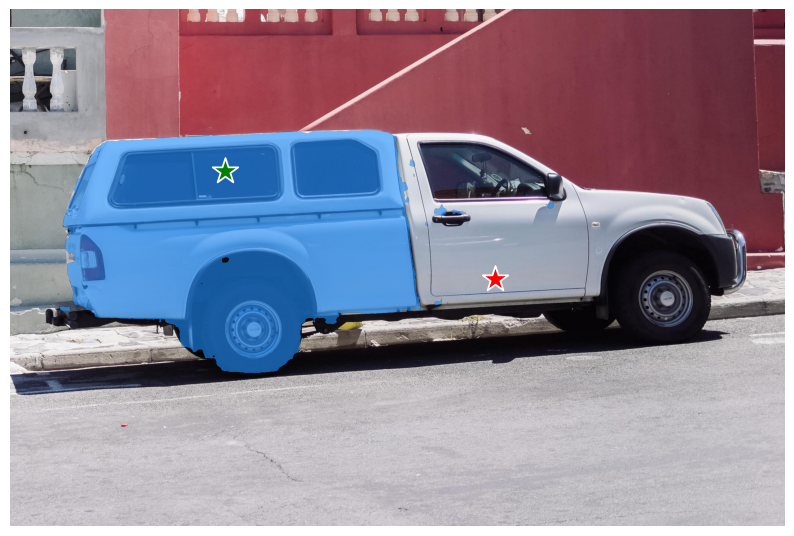

In [ ]:
plt.figure(figsize=(10, 10))
plt.imshow(image)
show_mask(masks, plt.gca())
show_points(input_point, input_label, plt.gca())
plt.axis('off')
plt.show()

##Prompt Engineering - Bounding Box

In [ ]:
input_box = np.array([425, 600, 700, 875])

In [ ]:
masks, _, _ = predictor.predict(
    point_coords=None,
    point_labels=None,
    box=input_box[None, :],
    multimask_output=False,
)

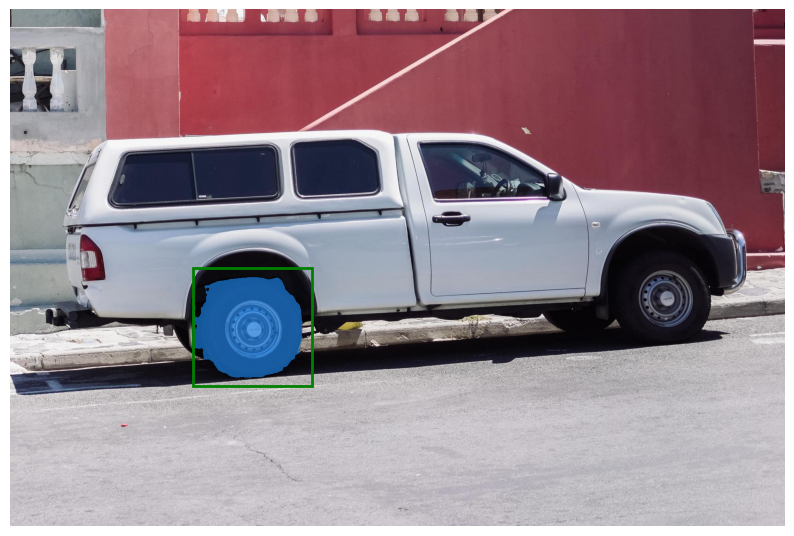

In [ ]:
plt.figure(figsize=(10, 10))
plt.imshow(image)
show_mask(masks[0], plt.gca())
show_box(input_box, plt.gca())
plt.axis('off')
plt.show()

##Multiple Prompt Engineering

In [ ]:
input_box = np.array([425, 600, 700, 875])
input_point = np.array([[575, 750]])
input_label = np.array([0])

In [ ]:
masks, _, _ = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    box=input_box,
    multimask_output=False,
)

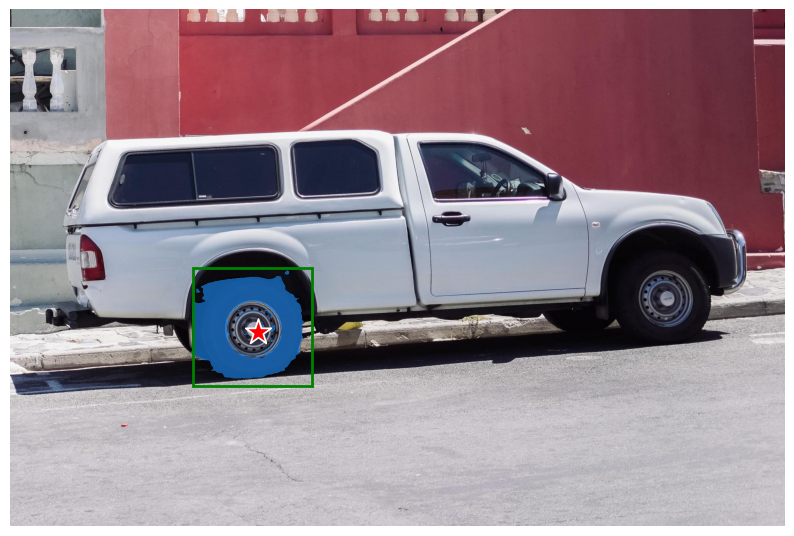

In [ ]:
plt.figure(figsize=(10, 10))
plt.imshow(image)
show_mask(masks[0], plt.gca())
show_box(input_box, plt.gca())
show_points(input_point, input_label, plt.gca())
plt.axis('off')
plt.show()

##Object Detector

In [ ]:
input_boxes = torch.tensor([
    [75, 275, 1725, 850],
    [425, 600, 700, 875],
    [1375, 550, 1650, 800],
    [1240, 675, 1400, 750],
], device=predictor.device)

In [ ]:
transformed_boxes = predictor.transform.apply_boxes_torch(input_boxes, image.shape[:2])
masks, _, _ = predictor.predict_torch(
    point_coords=None,
    point_labels=None,
    boxes=transformed_boxes,
    multimask_output=False,
)

In [ ]:
masks.shape  # (batch_size) x (num_predicted_masks_per_input) x H x W

torch.Size([4, 1, 1200, 1800])

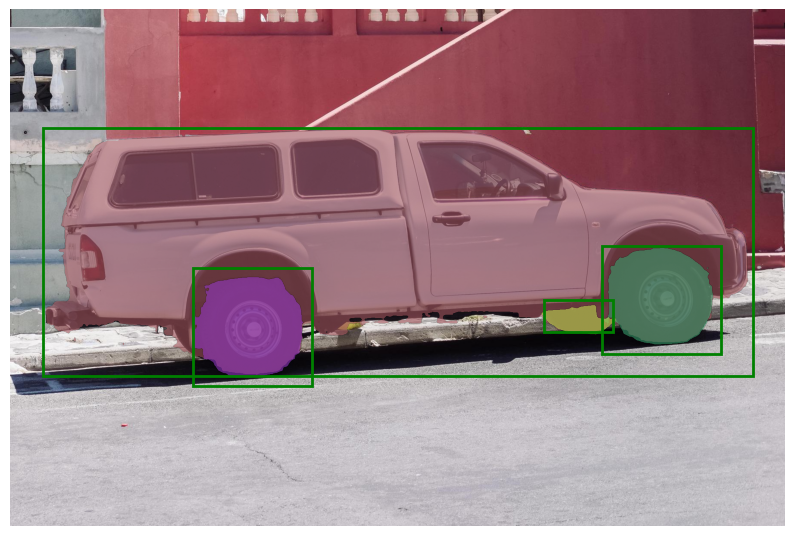

In [ ]:
plt.figure(figsize=(10, 10))
plt.imshow(image)
for mask in masks:
    show_mask(mask.cpu().numpy(), plt.gca(), random_color=True)
for box in input_boxes:
    show_box(box.cpu().numpy(), plt.gca())
plt.axis('off')
plt.show()

##Batch Inference

In [ ]:
image1 = image  # truck.jpg from above
image1_boxes = torch.tensor([
    [75, 275, 1725, 850],
    [425, 600, 700, 875],
    [1375, 550, 1650, 800],
    [1240, 675, 1400, 750],
], device=sam.device)

image2 = cv2.imread('images/groceries.jpg')
image2 = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)
image2_boxes = torch.tensor([
    [450, 170, 520, 350],
    [350, 190, 450, 350],
    [500, 170, 580, 350],
    [580, 170, 640, 350],
], device=sam.device)

In [ ]:
from segment_anything.utils.transforms import ResizeLongestSide
resize_transform = ResizeLongestSide(sam.image_encoder.img_size)

def prepare_image(image, transform, device):
    image = transform.apply_image(image)
    image = torch.as_tensor(image, device=device.device)
    return image.permute(2, 0, 1).contiguous()

In [ ]:
batched_input = [
     {
         'image': prepare_image(image1, resize_transform, sam),
         'boxes': resize_transform.apply_boxes_torch(image1_boxes, image1.shape[:2]),
         'original_size': image1.shape[:2]
     },
     {
         'image': prepare_image(image2, resize_transform, sam),
         'boxes': resize_transform.apply_boxes_torch(image2_boxes, image2.shape[:2]),
         'original_size': image2.shape[:2]
     }
]

In [ ]:
batched_output = sam(batched_input, multimask_output=False)

In [ ]:
batched_output[0].keys()

dict_keys(['masks', 'iou_predictions', 'low_res_logits'])

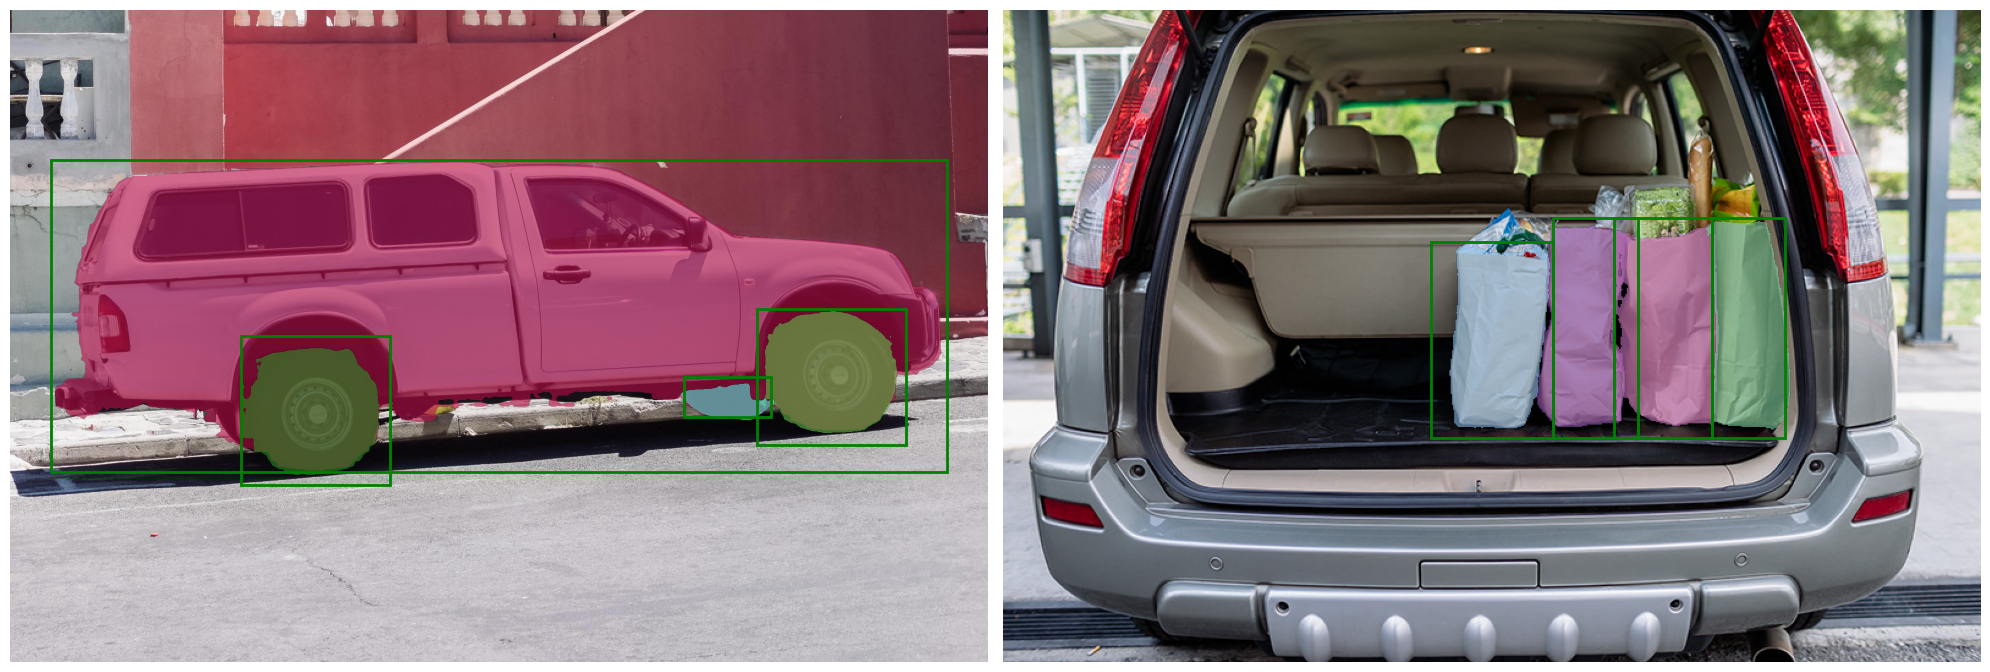

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(20, 20))

ax[0].imshow(image1)
for mask in batched_output[0]['masks']:
    show_mask(mask.cpu().numpy(), ax[0], random_color=True)
for box in image1_boxes:
    show_box(box.cpu().numpy(), ax[0])
ax[0].axis('off')

ax[1].imshow(image2)
for mask in batched_output[1]['masks']:
    show_mask(mask.cpu().numpy(), ax[1], random_color=True)
for box in image2_boxes:
    show_box(box.cpu().numpy(), ax[1])
ax[1].axis('off')

plt.tight_layout()
plt.show()